In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

In [26]:
df = pd.read_csv("Financial_Crisis.csv")
df.head()

,Date,Country,Stock_Index,Stock_Return,Stock_Volatility,Bond_Yield,Bond_Yield_Spread,Bond_Volatility,FX_Rate,FX_Return,FX_Volatility,VIX,Crisis_Label
0,2020-01-01,USA,1002.483571,0.000000,0.000000,1.569968,0.319078,0.015683,0.993248,0.000000,0.000000,15.047097,0
1,2020-01-02,USA,1001.792249,-0.068961,0.000000,1.546232,0.308604,0.019844,0.998555,0.534267,0.000000,15.698042,0
2,2020-01-03,USA,1005.030692,0.323265,0.000000,1.502982,0.304136,0.020090,0.992076,-0.648839,0.000000,23.821365,0
3,2020-01-04,USA,1012.645841,0.757703,0.000000,1.467653,0.281123,0.022363,0.996920,0.488328,0.000000,18.588396,0
4,2020-01-05,USA,1011.475074,-0.115615,0.366071,1.534911,0.294434,0.013166,0.981064,-1.590551,0.891436,17.423889,0


In [27]:
df.describe()

,Stock_Index,Stock_Return,Stock_Volatility,Bond_Yield,Bond_Yield_Spread,Bond_Volatility,FX_Rate,FX_Return,FX_Volatility,VIX,Crisis_Label
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,980.432041,-0.001586,0.484980,1.501761,0.300106,0.019901,1.000270,0.011335,1.450701,25.066687,0.220000
std,69.116490,0.516183,0.181837,0.051109,0.009994,0.004996,0.010123,1.420838,0.557833,8.818553,0.414315
min,793.278373,-1.680026,0.000000,1.315582,0.267569,0.003461,0.961633,-5.783285,0.000000,10.001444,0.000000
25%,948.262755,-0.344531,0.353563,1.467358,0.293461,0.016521,0.993498,-0.968107,1.035823,17.342131,0.000000
50%,982.469768,-0.002019,0.473054,1.501392,0.299956,0.019982,1.000167,0.016984,1.413646,25.054521,0.000000
75%,1032.749630,0.334145,0.602985,1.536128,0.306796,0.023357,1.006996,0.987749,1.814715,32.985327,0.000000
max,1137.936650,1.984618,1.149571,1.676453,0.339224,0.042395,1.039262,5.275906,4.012008,39.997029,1.000000


Each row in this dataset represents the financial state of a specific **country on a given day**.  
The features capture conditions in equity, bond, and foreign exchange markets, plus a crisis label indicating whether that day is considered part of a financial crisis.

### What each feature represents

- **Date**  
  The calendar date of the observation.

- **Country**  
  The country for which the financial indicators are measured (e.g., USA).

- **Stock_Index**  
  The level of a broad stock market index for the country on that date (e.g., an index similar to the S&P 500). Higher values indicate higher overall equity prices.

- **Stock_Return**  
  The **daily percentage change** in the stock index compared to the previous day.  
  - Positive values → stock market gained that day.  
  - Negative values → stock market lost value that day.

- **Stock_Volatility**  
  A measure of how much the stock index has been fluctuating over a recent window (e.g., rolling standard deviation of returns).  
  Higher values indicate a more turbulent, unstable equity market.

- **Bond_Yield**  
  The yield (interest rate) on a representative government bond for the country.  
  It reflects borrowing costs and market expectations about interest rates and risk.

- **Bond_Yield_Spread**  
  The difference between the country’s bond yield and a benchmark (e.g., US Treasuries or German Bunds).  
  Higher spreads usually indicate higher perceived credit or country risk.

- **Bond_Volatility**  
  A measure of how much bond yields have been fluctuating over a recent period.  
  High values indicate unstable bond markets and changing interest rate/risk perceptions.

- **FX_Rate**  
  The exchange rate of the country’s currency against a base currency (e.g., USD).  
  Values above/below 1 indicate appreciation/depreciation relative to that base.

- **FX_Return**  
  The **daily percentage change** in the FX rate compared to the previous day.  
  It captures how much the currency strengthened or weakened on that date.

- **FX_Volatility**  
  A measure of how much the FX rate has been fluctuating recently (e.g., rolling standard deviation of FX returns).  
  Higher values indicate a more unstable or uncertain currency market.

- **VIX**  
  A proxy for **global market volatility and fear**, often based on the volatility implied by options on a major stock index (like the S&P 500).  
  Higher VIX values mean markets expect more volatility and risk in the near term.

- **Crisis_Label**  
  A binary indicator of financial crisis conditions on that date for the given country:  
  - `0` → normal or non-crisis period  
  - `1` → crisis or high-stress period in financial markets  

In summary, each row is a snapshot of global and country-specific financial conditions for one country on one day, along multiple dimensions (equity, bonds, FX, volatility), along with a label indicating whether that environment corresponds to a financial crisis.

In [28]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Country", "Date"])

print(df.groupby("Country")["Date"].is_monotonic_increasing)


Country
Japan    True
UK       True
USA      True
Name: Date, dtype: bool


In [29]:
df.groupby("Country")["Date"].diff().value_counts().head()


Date
1 days    2997
Name: count, dtype: int64

In [30]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])


Series([], dtype: int64)


In [31]:
(df.isnull().mean() * 100).sort_values(ascending=False)


Date                 0.0
Country              0.0
Stock_Index          0.0
Stock_Return         0.0
Stock_Volatility     0.0
Bond_Yield           0.0
Bond_Yield_Spread    0.0
Bond_Volatility      0.0
FX_Rate              0.0
FX_Return            0.0
FX_Volatility        0.0
VIX                  0.0
Crisis_Label         0.0
dtype: float64

In [32]:
df["Crisis_Label"].value_counts(normalize=True)


Crisis_Label
0    0.78
1    0.22
Name: proportion, dtype: float64

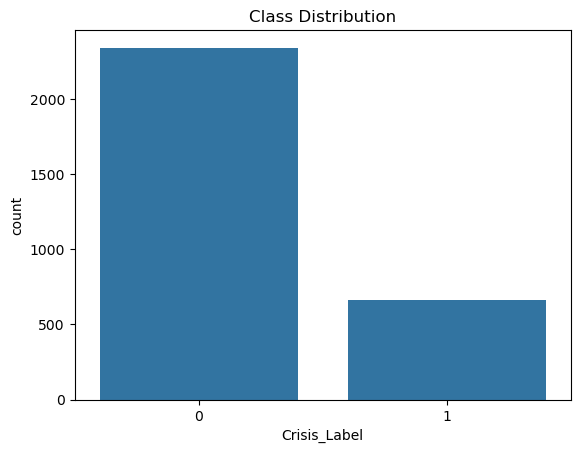

In [33]:
sns.countplot(x="Crisis_Label", data=df)
plt.title("Class Distribution")
plt.show()


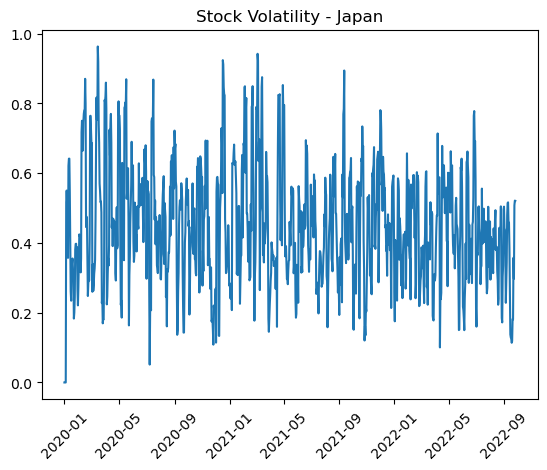

In [34]:
country = df["Country"].unique()[0]
temp = df[df["Country"] == country]

plt.figure()
plt.plot(temp["Date"], temp["Stock_Volatility"])
plt.title(f"Stock Volatility - {country}")
plt.xticks(rotation=45)
plt.show()


In [35]:
df_model = df.drop(columns=["Date", "Country"])
X = df_model.drop(columns=["Crisis_Label"])
y = df_model["Crisis_Label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
y_proba = model.predict_proba(X_test_scaled)[:, 1]
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       467
           1       0.96      0.98      0.97       133

    accuracy                           0.99       600
   macro avg       0.98      0.99      0.98       600
weighted avg       0.99      0.99      0.99       600

ROC AUC Score: 0.9990661879538246


True Positives: 131
False Positives: 5
True Negatives: 462
False Negatives: 2


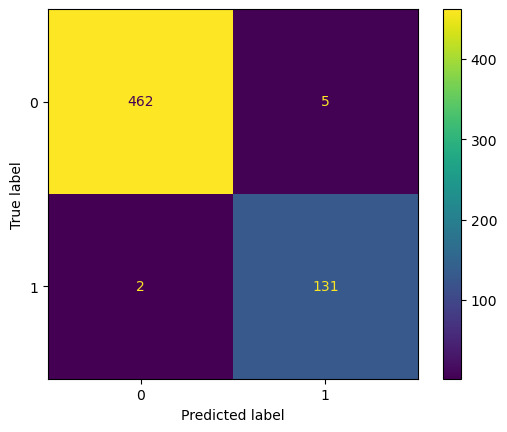

In [36]:
# let's print true positives, false positives, true negatives, and false negatives
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"True Positives: {tp}")
print(f"False Positives: {fp}")
print(f"True Negatives: {tn}")
print(f"False Negatives: {fn}")

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot()


              precision    recall  f1-score   support

           0       0.99      0.99      0.99       467
           1       0.96      0.98      0.97       133

    accuracy                           0.98       600
   macro avg       0.97      0.98      0.98       600
weighted avg       0.99      0.98      0.99       600

ROC-AUC: 0.9987039332807394


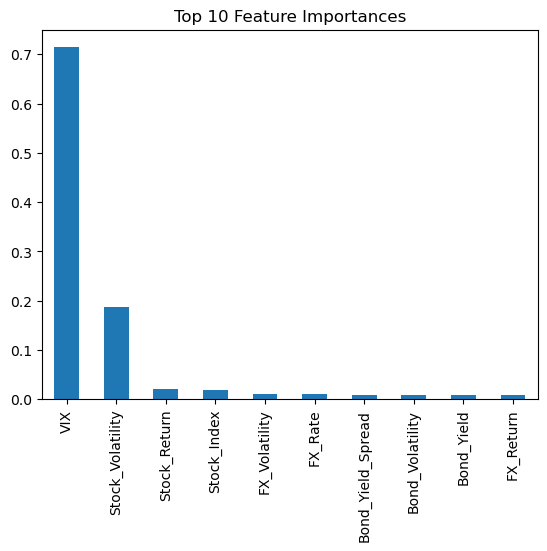

VIX                  0.713850
Stock_Volatility     0.188128
Stock_Return         0.021002
Stock_Index          0.019162
FX_Volatility        0.011406
FX_Rate              0.010193
Bond_Yield_Spread    0.009713
Bond_Volatility      0.009277
Bond_Yield           0.008987
FX_Return            0.008283
dtype: float64


In [37]:
clf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


importances = clf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure()
feat_imp.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances")
plt.show()

print(feat_imp.head(10))


In [38]:
# since VIX is the most important feature, let's try without it
X_no_vix = X_train_scaled.copy()
vix_index = X.columns.get_loc("VIX")
X_no_vix = np.delete(X_no_vix, vix_index, axis=1)
X_test_no_vix = X_test_scaled.copy()
X_test_no_vix = np.delete(X_test_no_vix, vix_index, axis=1)
clf_no_vix = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)
clf_no_vix.fit(X_no_vix, y_train)
y_pred_no_vix = clf_no_vix.predict(X_test_no_vix)
y_prob_no_vix = clf_no_vix.predict_proba(X_test_no_vix)[:,1]
print("Without VIX:")
print(classification_report(y_test, y_pred_no_vix))
print("ROC-AUC without VIX:", roc_auc_score(y_test, y_prob_no_vix))


Without VIX:
              precision    recall  f1-score   support

           0       0.82      0.98      0.90       467
           1       0.81      0.26      0.39       133

    accuracy                           0.82       600
   macro avg       0.82      0.62      0.64       600
weighted avg       0.82      0.82      0.78       600

ROC-AUC without VIX: 0.6697444897039171


In [39]:
#now let's try with only VIX
X_vix_only = X_train_scaled.copy()
vix_index = X.columns.get_loc("VIX")
X_vix_only = X_vix_only[:, vix_index].reshape(-1, 1)
X_test_vix_only = X_test_scaled.copy()
X_test_vix_only = X_test_vix_only[:, vix_index].reshape(-1, 1)
clf_vix_only = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)
clf_vix_only.fit(X_vix_only, y_train)
y_pred_vix_only = clf_vix_only.predict(X_test_vix_only)
y_prob_vix_only = clf_vix_only.predict_proba(X_test_vix_only)[:,1]
print("With only VIX:")
print(classification_report(y_test, y_pred_vix_only))
print("ROC-AUC with only VIX:", roc_auc_score(y_test, y_prob_vix_only))

With only VIX:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       467
           1       0.77      0.78      0.78       133

    accuracy                           0.90       600
   macro avg       0.85      0.86      0.86       600
weighted avg       0.90      0.90      0.90       600

ROC-AUC with only VIX: 0.8823477322857465


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# ==========================================
# 1. UTILITY FUNCTIONS (Inspired by util.py)
# ==========================================

class ADSimpleCostModel:
    """
    A simple cost model for Anomaly Detection.
    c_alrm: Cost of a False Positive (False Alarm)
    c_missed: Cost of a False Negative (Missed Crisis)
    """
    def __init__(self, c_alrm, c_missed):
        self.c_alrm = c_alrm
        self.c_missed = c_missed

    def cost(self, y_true, y_pred):
        # Calculate False Positives (FP) and False Negatives (FN)
        # y_true: actual labels (1 = Crisis, 0 = Normal)
        # y_pred: predicted labels (1 = Anomaly/Crisis, 0 = Normal)
        
        # FP: Predicted 1, Actual 0
        fp = np.sum((y_pred == 1) & (y_true == 0))
        # FN: Predicted 0, Actual 1
        fn = np.sum((y_pred == 0) & (y_true == 1))
        
        return fp * self.c_alrm + fn * self.c_missed

def opt_thr(scores, y_true, cmodel, method='density'):
    """
    Optimizes the threshold based on the cost model.
    method: 'density' (lower score is anomaly) or 'error' (higher score is anomaly)
    """
    # Generate candidate thresholds based on the scores
    # We take a sample of scores to speed up if data is large
    thr_range = np.linspace(np.min(scores), np.max(scores), 100)
    
    best_thr = None
    best_cost = float('inf')
    
    for thr in thr_range:
        if method == 'density':
            # For density, scores below threshold are anomalies (1)
            y_pred = (scores < thr).astype(int)
        else: # method == 'error'
            # For reconstruction error, scores above threshold are anomalies (1)
            y_pred = (scores > thr).astype(int)
            
        current_cost = cmodel.cost(y_true, y_pred)
        
        if current_cost < best_cost:
            best_cost = current_cost
            best_thr = thr
            
    return best_thr, best_cost

def plot_cost_curve(scores, y_true, cmodel, method='density', title="Cost Curve"):
    thr_range = np.linspace(np.min(scores), np.max(scores), 100)
    costs = []
    for thr in thr_range:
        if method == 'density':
            y_pred = (scores < thr).astype(int)
        else:
            y_pred = (scores > thr).astype(int)
        costs.append(cmodel.cost(y_true, y_pred))
    
    plt.figure(figsize=(10, 4))
    plt.plot(thr_range, costs)
    plt.title(title)
    plt.xlabel("Threshold")
    plt.ylabel("Cost")
    plt.grid(True)
    plt.show()

# ==========================================
# 2. DATA LOADING & PREPROCESSING
# ==========================================

# Configuration
RANDOM_STATE = 42
# Define Costs: Missing a crisis is 50x worse than a false alarm
C_ALARM = 1
C_MISSED = 4
c_model = ADSimpleCostModel(C_ALARM, C_MISSED)

# Load Data (Replace 'your_dataset.csv' with the actual file path)
# Assuming columns: Stock_Index, Stock_Return, Stock_Volatility, Bond_Yield, 
# Bond_Yield_Spread, Bond_Volatility, FX_Rate, FX_Return, VIX, Crisis_Label
try:
    df = pd.read_csv('Financial_Crisis.csv') # CHANGE THIS FILENAME
except FileNotFoundError:
    print("Dataset not found. Creating dummy data for demonstration...")
    # Create dummy data if file not present
    N = 2000
    df = pd.DataFrame(np.random.randn(N, 9), columns=[
        'Stock_Index', 'Stock_Return', 'Stock_Volatility', 'Bond_Yield', 
        'Bond_Yield_Spread', 'Bond_Volatility', 'FX_Rate', 'FX_Return', 'VIX'])
    df['Crisis_Label'] = np.random.choice([0, 1], size=N, p=[0.95, 0.05])

horizon = 14

df["Crisis_Forward"] = df["Crisis_Label"].shift(-horizon)
df = df.dropna()

# Feature Selection
features = ['Stock_Return', 'Stock_Volatility', 'Bond_Yield_Spread', 'Bond_Volatility', 'FX_Return', 'VIX']
target = 'Crisis_Forward'

X = df[features].values
y = df[target].values

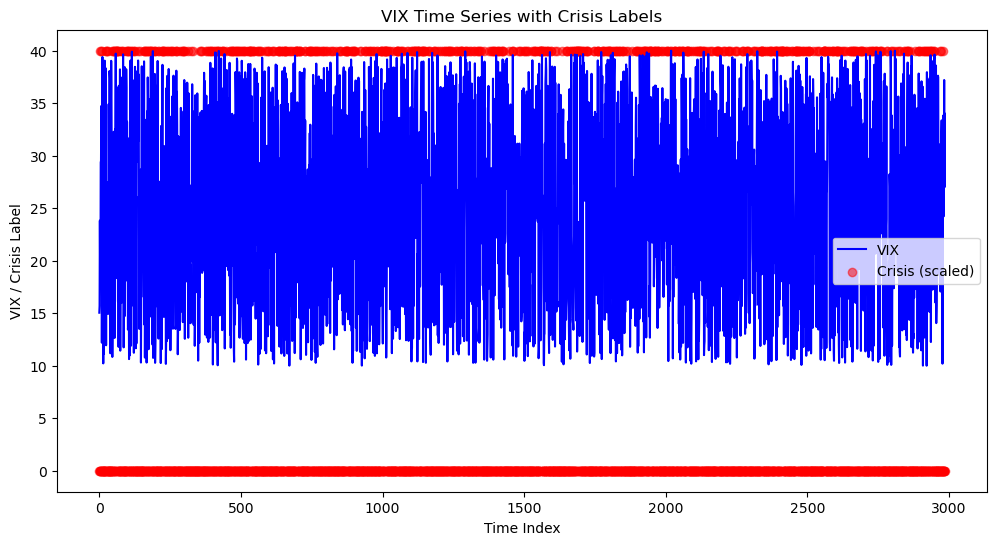

In [41]:
# we plot the time series (with the label) to identify emprically a time window with mostly normal data (no crises) to train the density-based model
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['VIX'], label='VIX', color='blue')
plt.scatter(df.index, df['Crisis_Forward']*df['VIX'].max(), label='Crisis (scaled)', color='red', alpha=0.5)
plt.title("VIX Time Series with Crisis Labels")
plt.xlabel("Time Index")
plt.ylabel("VIX / Crisis Label")
plt.legend()
plt.show() 

In [42]:
# Chronological Split (Train: 60%, Val: 20%, Test: 20%)
n = len(df)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

X_train_all = X[:train_end]
y_train_all = y[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]

# Filter Training set to only include NORMAL data (Label=0)
# We want to learn the distribution of "Normalcy"
X_train_normal = X_train_all[y_train_all == 0]

# Standardization (Fit on Train Normal, Apply to all)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_normal)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training Data (Normal only): {X_train_scaled.shape}")
print(f"Validation Data: {X_val_scaled.shape}")
print(f"Test Data: {X_test_scaled.shape}")


Training Data (Normal only): (1401, 6)
Validation Data: (597, 6)
Test Data: (598, 6)



--- Approach 1: KDE ---
Optimal KDE Threshold: -8.47 | Validation Cost: 429
KDE Test Confusion Matrix:
 [[122 344]
 [ 36  96]]

--- Approach 2: GMM ---
Optimal GMM Threshold: -6.59 | Validation Cost: 434
GMM Test Confusion Matrix:
 [[ 47 419]
 [ 15 117]]

--- Approach 3: Autoencoders ---
Optimal AE Threshold: 0.1830 | Validation Cost: 432
Autoencoder Test Confusion Matrix:
 [[ 54 412]
 [ 23 109]]


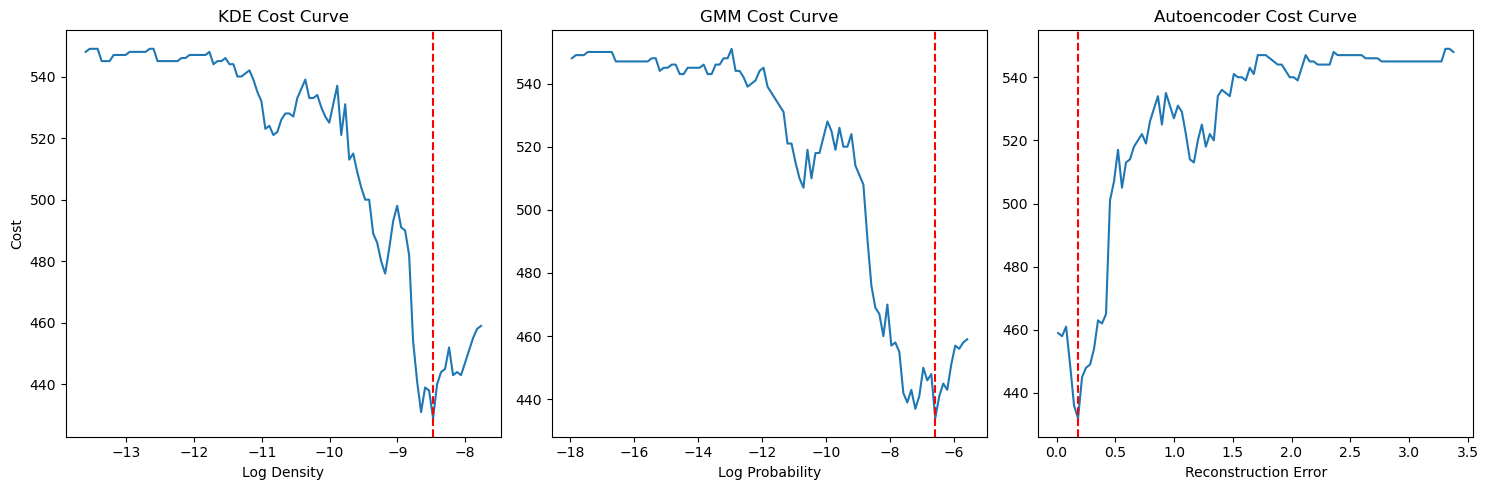

In [43]:

# ==========================================
# 3. APPROACH 1: KERNEL DENSITY ESTIMATION (KDE)
# ==========================================
print("\n--- Approach 1: KDE ---")

# 1. Fit KDE
# Bandwidth is a hyperparameter. In a real scenario, you'd use GridSearchCV.
kde = KernelDensity(kernel='gaussian', bandwidth=1.0)
kde.fit(X_train_scaled)

# 2. Score (Log Density)
val_scores_kde = kde.score_samples(X_val_scaled)
test_scores_kde = kde.score_samples(X_test_scaled)

# 3. Optimize Threshold using Cost Function
# For KDE, LOWER score means anomaly
kde_thr, kde_cost = opt_thr(val_scores_kde, y_val, c_model, method='density')
print(f"Optimal KDE Threshold: {kde_thr:.2f} | Validation Cost: {kde_cost}")

# 4. Evaluate on Test
y_pred_kde = (test_scores_kde < kde_thr).astype(int)
print("KDE Test Confusion Matrix:\n", confusion_matrix(y_test, y_pred_kde))

# ==========================================
# 4. APPROACH 2: GAUSSIAN MIXTURE MODELS (GMM)
# ==========================================
print("\n--- Approach 2: GMM ---")

# 1. Fit GMM
# Number of components (n_components) usually found via BIC/AIC
gmm = GaussianMixture(n_components=4, random_state=RANDOM_STATE)
gmm.fit(X_train_scaled)

# 2. Score (Weighted Log Probability)
val_scores_gmm = gmm.score_samples(X_val_scaled)
test_scores_gmm = gmm.score_samples(X_test_scaled)

# 3. Optimize Threshold
# For GMM, LOWER score means anomaly
gmm_thr, gmm_cost = opt_thr(val_scores_gmm, y_val, c_model, method='density')
print(f"Optimal GMM Threshold: {gmm_thr:.2f} | Validation Cost: {gmm_cost}")

# 4. Evaluate on Test
y_pred_gmm = (test_scores_gmm < gmm_thr).astype(int)
print("GMM Test Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gmm))

# ==========================================
# 5. APPROACH 3: AUTOENCODERS
# ==========================================
print("\n--- Approach 3: Autoencoders ---")

# 1. Build Autoencoder
input_dim = X_train_scaled.shape[1]
latent_dim = 2 # Compression to capture essential features

# Encoder
input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(16, activation='relu')(input_layer)
encoded = layers.Dense(8, activation='relu')(encoded)
latent = layers.Dense(latent_dim, activation='relu')(encoded)

# Decoder
decoded = layers.Dense(8, activation='relu')(latent)
decoded = layers.Dense(16, activation='relu')(decoded)
output_layer = layers.Dense(input_dim, activation='linear')(decoded) # Linear for reconstruction

autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# 2. Train
# Use EarlyStopping to prevent overfitting
es = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Note: We use X_val_scaled as validation data for the training process itself (to monitor loss),
# but the anomaly thresholding is done separately.
autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=50,
    batch_size=32,
    shuffle=True,
    validation_data=(X_val_scaled, X_val_scaled), # We reconstruct the input
    callbacks=[es],
    verbose=0
)

# 3. Score (Reconstruction Error)
# Error = Mean Squared Error between Input and Reconstruction
X_val_recon = autoencoder.predict(X_val_scaled, verbose=0)
val_mse = np.mean(np.power(X_val_scaled - X_val_recon, 2), axis=1)

X_test_recon = autoencoder.predict(X_test_scaled, verbose=0)
test_mse = np.mean(np.power(X_test_scaled - X_test_recon, 2), axis=1)

# 4. Optimize Threshold
# For AE, HIGHER error means anomaly
ae_thr, ae_cost = opt_thr(val_mse, y_val, c_model, method='error')
print(f"Optimal AE Threshold: {ae_thr:.4f} | Validation Cost: {ae_cost}")

# 5. Evaluate on Test
y_pred_ae = (test_mse > ae_thr).astype(int)
print("Autoencoder Test Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ae))

# ==========================================
# FINAL VISUALIZATION
# ==========================================
# Visualizing the cost curves to see sensitivity
plt.figure(figsize=(15, 5))

# KDE Plot
plt.subplot(1, 3, 1)
kde_range = np.linspace(np.min(val_scores_kde), np.max(val_scores_kde), 100)
kde_costs = [c_model.cost(y_val, (val_scores_kde < t).astype(int)) for t in kde_range]
plt.plot(kde_range, kde_costs)
plt.axvline(kde_thr, color='r', linestyle='--', label='Opt Thr')
plt.title('KDE Cost Curve')
plt.xlabel('Log Density')
plt.ylabel('Cost')

# GMM Plot
plt.subplot(1, 3, 2)
gmm_range = np.linspace(np.min(val_scores_gmm), np.max(val_scores_gmm), 100)
gmm_costs = [c_model.cost(y_val, (val_scores_gmm < t).astype(int)) for t in gmm_range]
plt.plot(gmm_range, gmm_costs)
plt.axvline(gmm_thr, color='r', linestyle='--', label='Opt Thr')
plt.title('GMM Cost Curve')
plt.xlabel('Log Probability')

# AE Plot
plt.subplot(1, 3, 3)
ae_range = np.linspace(np.min(val_mse), np.max(val_mse), 100)
ae_costs = [c_model.cost(y_val, (val_mse > t).astype(int)) for t in ae_range]
plt.plot(ae_range, ae_costs)
plt.axvline(ae_thr, color='r', linestyle='--', label='Opt Thr')
plt.title('Autoencoder Cost Curve')
plt.xlabel('Reconstruction Error')

plt.tight_layout()
plt.show()